In [18]:
from typing import Callable, Tuple
from dataclasses import dataclass

import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import sympy

In [19]:
from mc_core.utils.montecarlo import monte_carlo, MonteCarloEstimate
from mc_core.importance_sampling import *

## Rare Event Estimation

We would like to calculate the probability of a rare event in this notebook using different Monte Carlo methods and compare their performance

## $ \mathbb{P}(Z > 4.5) $
In this problem we will estimate the tail probabilities of the standard normal distribution

$$ \mathbb{P}(Z > 4.5) = \int_{4.5}^{+\infty} \frac{1}{\sqrt{2 \pi}} e^{-\frac{1}{2}z^2}dz$$

In [20]:
z = sympy.Symbol('z')
fz = sympy.exp(-z**2 /2)/sympy.sqrt(2 * sympy.pi)
Pz = sympy.integrals.integrate(fz, (z, 4.5, sympy.oo)).evalf()
print("Analytical Solution: ", Pz)

Analytical Solution:  3.39767312476808e-6


## Vaniall Monte Carlo

we will generate $10^5$ samples from standard normal and try to estimate the $ \mathbb{P}(Z > 4.5) $ using simple Monte Carlo

In [21]:
num_samples = 100000
standard_normal_sampler = np.random.randn

def g_evaluator(x: np.ndarray) -> np.ndarray:
    return x > 4.5

Pz_mc_estimate = monte_carlo(num_samples, standard_normal_sampler, g_evaluator, cumsum=False)
print(f"MC estimate with {num_samples:,} samples = {Pz_mc_estimate.estimate:5E}")
print(f"Truth                         = {Pz:5E}")

MC estimate with 100,000 samples = 0.000000E+00
Truth                         = 3.39767312476808E-6


In [22]:
def proposal_sampler(n: int) -> np.ndarray:
    return stats.expon.rvs(size=n, loc=4.5, scale = 1)

def proposal_pdf(x: np.ndarray) ->np.ndarray:
    return stats.expon.pdf(x, loc=4.5, scale = 1)

def target_pdf(x: np.ndarray) -> np.ndarray:
    return stats.norm.pdf(x)

Pz_is = importance_sampling(num_samples,proposal_sampler,proposal_pdf,target_pdf, g_evaluator, False)
print(f"Important Sampling estimate with {num_samples:,} samples = {Pz_is.estimate_is:5E}")
print(f"Truth                         = {Pz:5E}")


Important Sampling estimate with 100,000 samples = 3.390223E-06
Truth                         = 3.39767312476808E-6


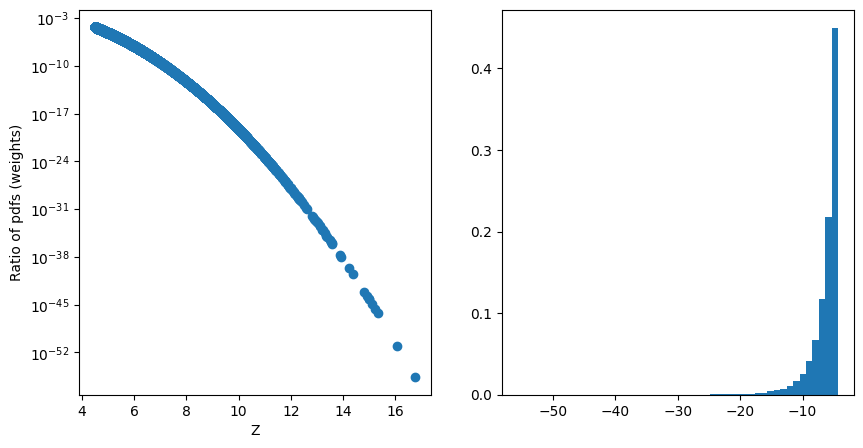

In [23]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
ax1.semilogy(Pz_is.x_samples, Pz_is.w_norm, 'o')  # plot the normalized weights
ax1.set_xlabel("Z")
ax1.set_ylabel("Ratio of pdfs (weights)")
ax2.hist(np.log10(Pz_is.w_norm, Pz_is.w_norm + 1e-20), bins=50, density=True)
plt.show()